# 1.0 - Análisis Exploratorio de Datos (EDA)

## Telco Customer Churn

Análisis exploratorio del dataset de churn de telecomunicaciones para
entender la estructura de los datos, la calidad de los mismos y las
relaciones entre las variables y la variable objetivo **Churn**.

In [1]:
import sys
from pathlib import Path

# Permite importar los módulos de src/ desde el notebook
sys.path.insert(0, str(Path.cwd().parent))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from src.data.make_dataset import load_raw_data
from src.visualization.visualize import (
    plot_categorical_by_target,
    plot_correlation_matrix,
    plot_numeric_distributions,
    plot_target_distribution,
)

pd.set_option("display.max_columns", None)
plt.style.use("seaborn-v0_8-whitegrid")

## 1. Carga de datos

Cargamos el dataset crudo almacenado en `data/raw/`.

In [2]:
df = load_raw_data()
print(f"Shape: {df.shape}")
df.head()

Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 2. Estructura y tipos de datos

Revisamos los tipos de cada columna para identificar variables numéricas
y categóricas.

In [3]:
df.info()
print("\nValores nulos por columna:")
print(df.isna().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


## 3. Calidad de datos

La columna `TotalCharges` está almacenada como texto y contiene 11 registros
en blanco (clientes con `tenure == 0`). La convertimos a numérica.

In [4]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
print(f"NaN tras conversión en TotalCharges: {df['TotalCharges'].isna().sum()}")
print(f"Filas con tenure==0: {(df['tenure'] == 0).sum()}")

NaN tras conversión en TotalCharges: 11
Filas con tenure==0: 11


## 4. Estadísticas descriptivas

Resumen de las variables numéricas y la distribución de la variable objetivo.

In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,7043.0,0.162147,0.368612,0.00,0.00,0.000,0.0000,1.00
tenure,7043.0,32.371149,24.559481,0.00,9.00,29.000,55.0000,72.00
MonthlyCharges,7043.0,64.761692,30.090047,18.25,35.50,70.350,89.8500,118.75
TotalCharges,7032.0,2283.300441,2266.771362,18.80,401.45,1397.475,3794.7375,8684.80


In [6]:
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

### Desbalance de clases

La variable objetivo está desbalanceada (~73% No / ~27% Yes). Esto debe
considerarse en la selección de métricas (**F1, AUC-ROC, Recall**) y en el
entrenamiento (pesos de clase / técnicas de resampling).

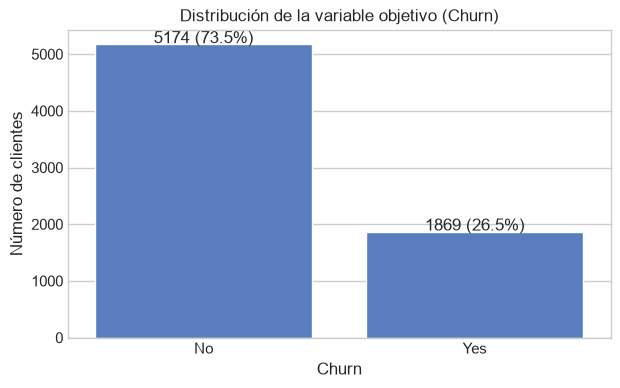

In [7]:
plot_target_distribution(df, output_dir=Path.cwd().parent / "reports" / "figures")

## 5. Análisis univariado de variables categóricas

Proporción de churn dentro de cada categoría de las variables categóricas.
Las categorías `No phone service` y `No internet service` codifican la
ausencia del servicio base.

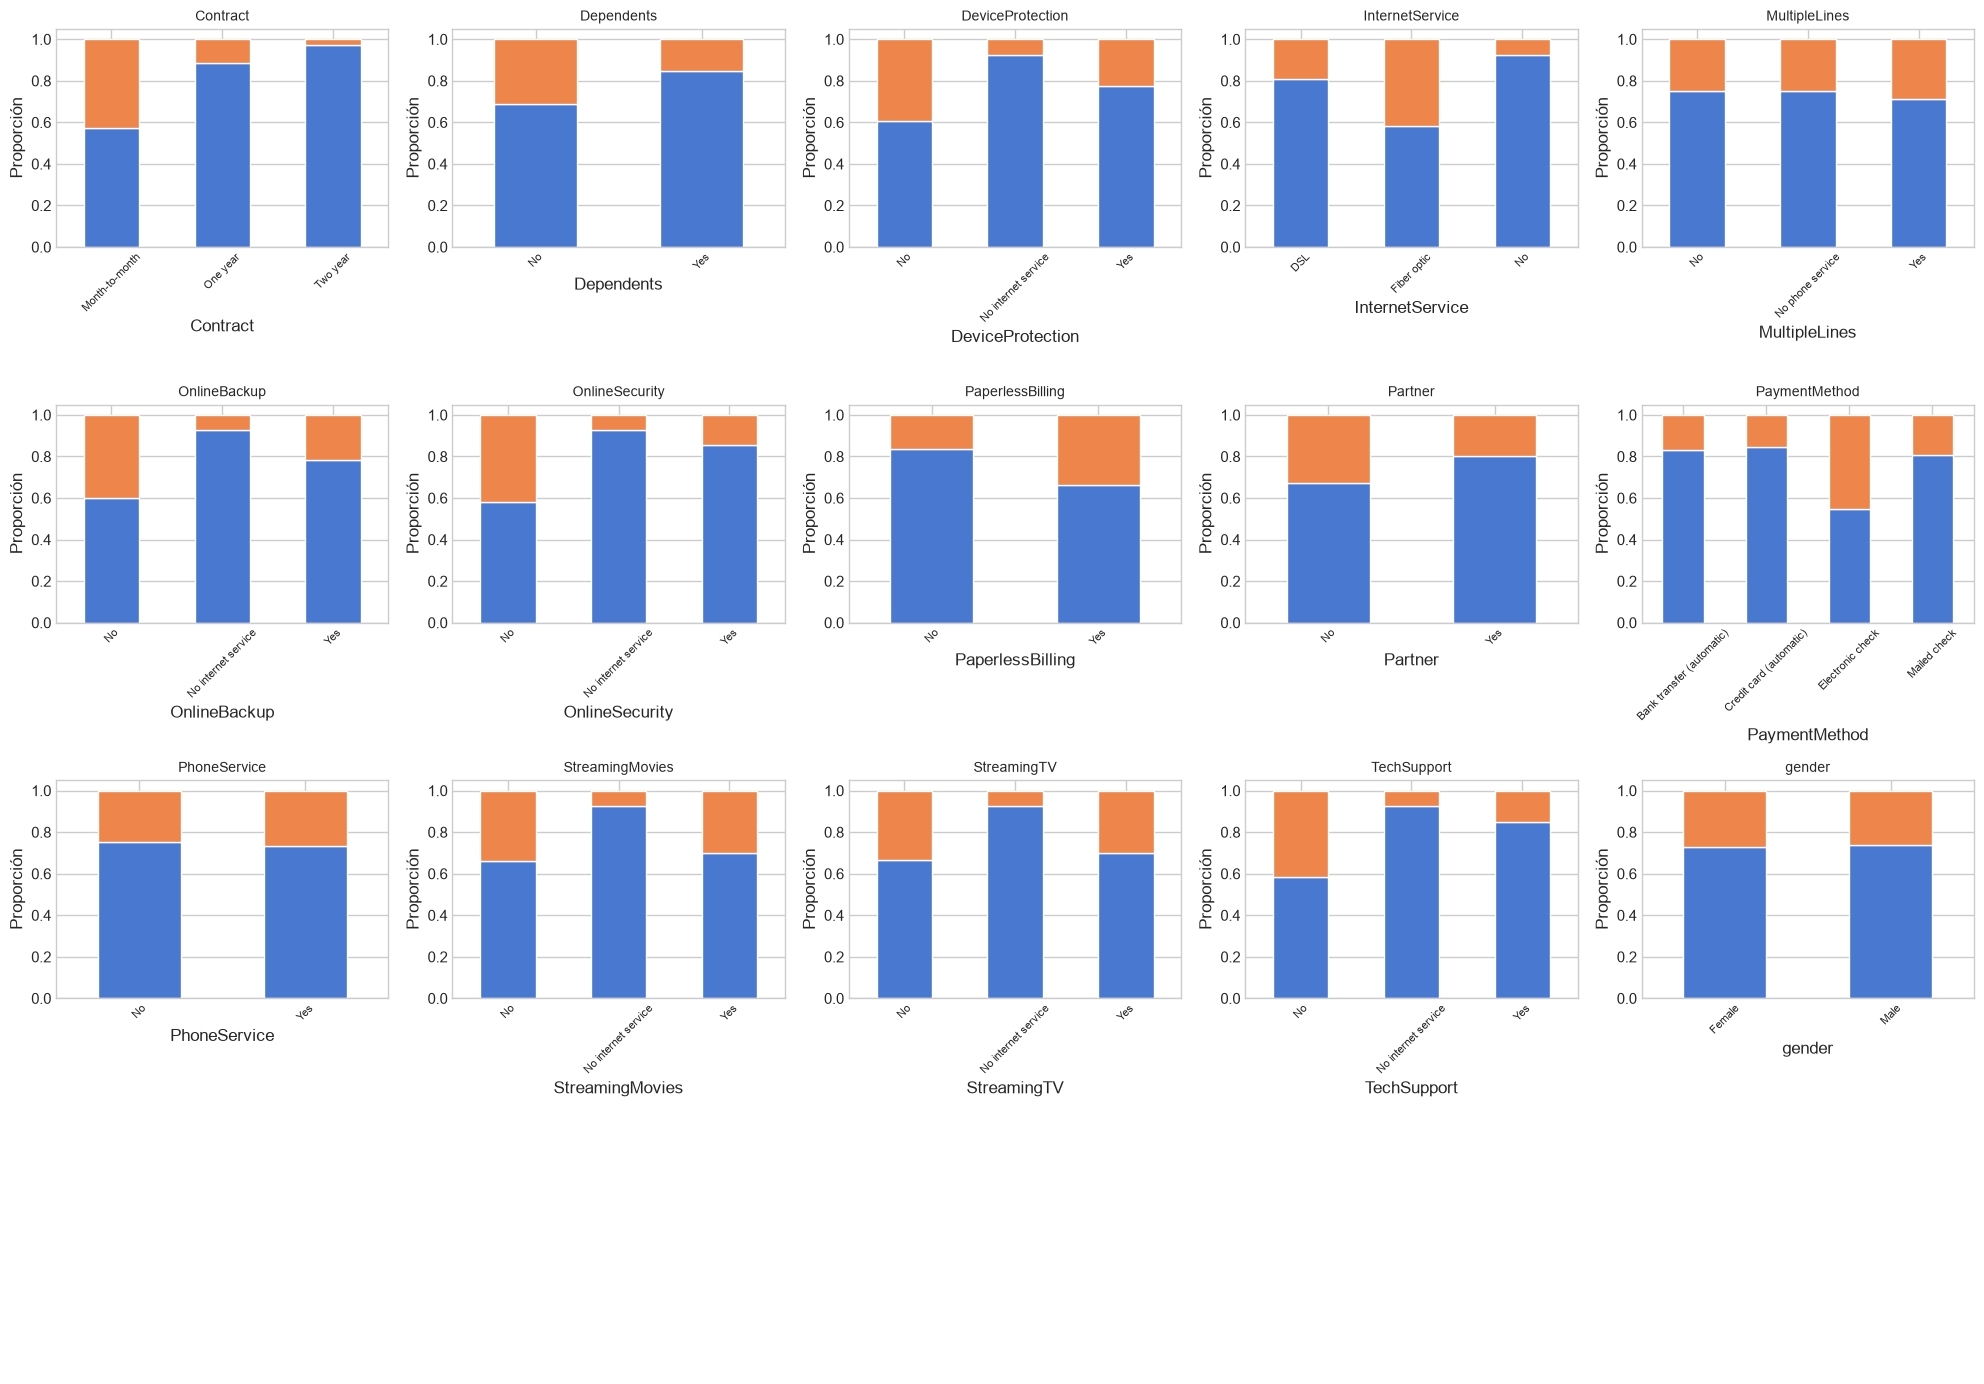

In [8]:
plot_categorical_by_target(df, output_dir=Path.cwd().parent / "reports" / "figures")
plt.show()

## 6. Variables numéricas vs Churn

Distribuciones de `tenure`, `MonthlyCharges` y `TotalCharges` separadas por
la variable objetivo.

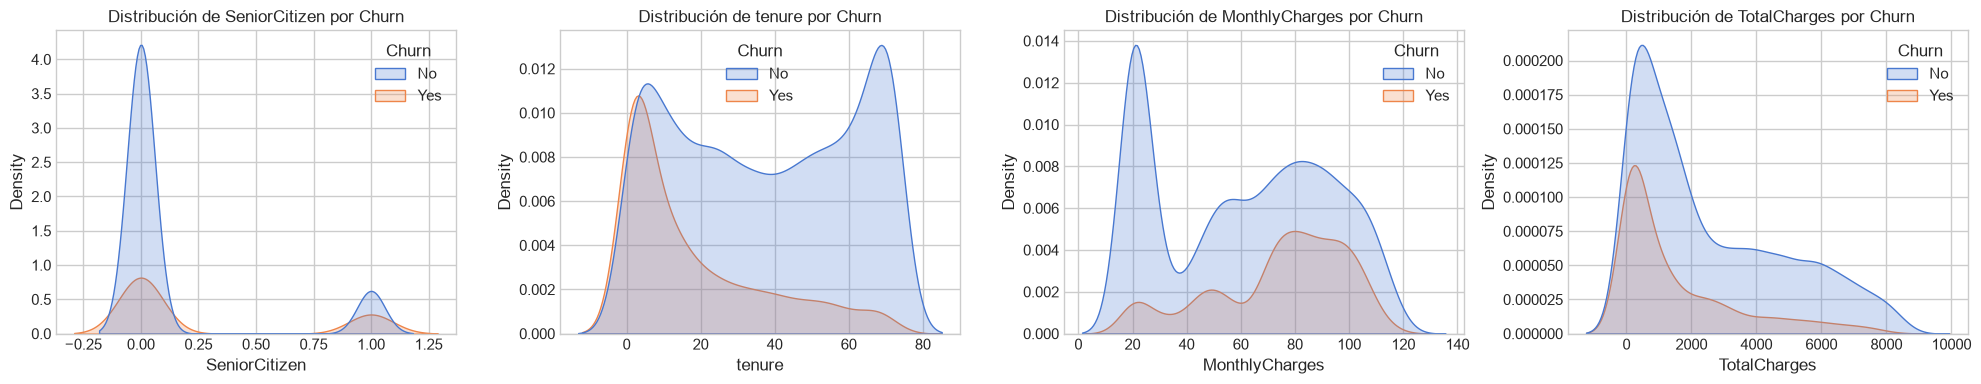

In [9]:
plot_numeric_distributions(df, output_dir=Path.cwd().parent / "reports" / "figures")
plt.show()

## 7. Correlaciones

Matriz de correlación entre las variables numéricas.

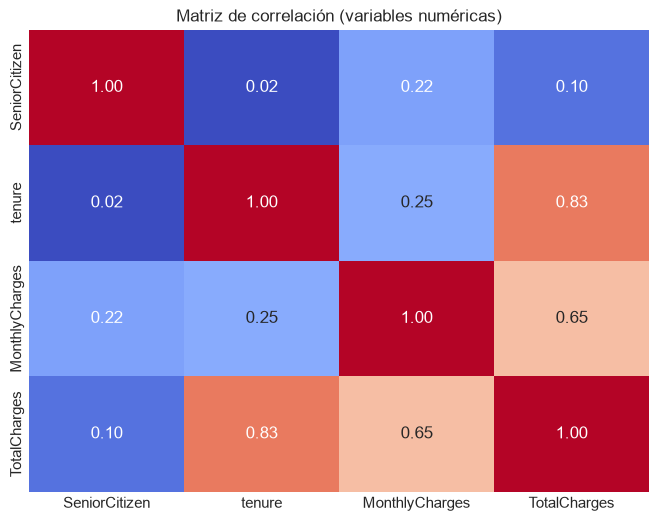

In [10]:
plot_correlation_matrix(df, output_dir=Path.cwd().parent / "reports" / "figures")
plt.show()

## 8. Conclusiones preliminares

- Dataset de **7043 clientes** y **21 columnas**, sin valores nulos reales
  (solo espacios en blanco en `TotalCharges`).
- **Desbalance de target**: la clase `Churn=Yes` representa ~27% del total.
- El **tipo de contrato** (`Month-to-month`) y el **método de pago**
  (`Electronic check`) muestran tasas de churn notablemente más altas.
- Los **cargos mensuales** (`MonthlyCharges`) son más altos en clientes que
  abandonan, mientras que `tenure` es claramente menor.
- `TotalCharges` y `tenure` están fuertemente correlacionadas (acumulado
  temporal), por lo que ofrecen información redundante.
- En el preprocesamiento habrá que: convertir `TotalCharges` a numérico,
  imputar los 11 valores faltantes y codificar las variables categóricas.

---

*Fin del notebook de EDA. Siguiente paso: `2.0-preprocessing.ipynb`.*